In [1]:
# =============================================================
# 🧮 Convex and Matrix Optimization for Image Reconstruction
# =============================================================
# Description: Demonstration of convex optimization methods
#              (nuclear norm minimization) for image denoising
#              and matrix recovery.
# =============================================================

# Step 0: Setup
!pip install cvxpy scikit-image matplotlib numpy tqdm --quiet

import cvxpy as cp
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color, img_as_float
from skimage.metrics import peak_signal_noise_ratio as psnr
from tqdm import tqdm

np.random.seed(42)


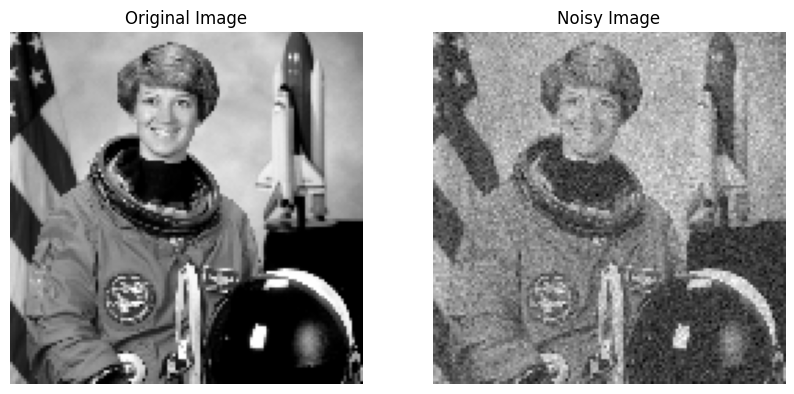

In [3]:
# Load a standard grayscale image
image = color.rgb2gray(data.astronaut())
image = img_as_float(image)
image = image[::4, ::4]  # downsample for speed
original = image.copy()

# Add Gaussian noise
noise_std = 0.1
noisy_image = original + noise_std * np.random.randn(*original.shape)

# Display
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(original, cmap='gray')
axs[0].set_title("Original Image")
axs[1].imshow(noisy_image, cmap='gray')
axs[1].set_title("Noisy Image")
for ax in axs: ax.axis('off')
plt.show()


In [4]:
# Define the problem
M = noisy_image
m, n = M.shape
X = cp.Variable((m, n))
lambda_reg = 1.0  # regularization parameter

# Objective function
objective = cp.Minimize(cp.normNuc(X) + (lambda_reg/2) * cp.norm(X - M, "fro")**2)
prob = cp.Problem(objective)

# Solve
prob.solve(verbose=True)

denoised_image = X.value


(CVXPY) Oct 27 06:42:51 PM: Your problem has 16384 variables, 0 constraints, and 0 parameters.
(CVXPY) Oct 27 06:42:51 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Oct 27 06:42:51 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Oct 27 06:42:51 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Oct 27 06:42:51 PM: Your problem is compiled with the CPP canonicalization backend.
(CVXPY) Oct 27 06:42:51 PM: Compiling problem (target solver=SCS).
(CVXPY) Oct 27 06:42:51 PM: Reduction chain: Dcp2Cone -> CvxAttr2Constr -> ConeMatrixStuffing -> SCS
(CVXPY) Oct 27 06:42:51 PM: Applying reduction Dcp2Cone
(CVXPY) Oct 27 06:42:51 PM: Applying reduction CvxAttr2Constr
(CVXPY) Oct 27 06:42:51 PM: Applying reduction ConeMatrixStuffing


                                     CVXPY                                     
                                     v1.6.7                                    
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------


(CVXPY) Oct 27 06:42:52 PM: Applying reduction SCS
(CVXPY) Oct 27 06:42:52 PM: Finished problem compilation (took 4.811e-01 seconds).
(CVXPY) Oct 27 06:42:52 PM: Invoking solver SCS  to obtain a solution.


-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------
------------------------------------------------------------------
	       SCS v3.2.9 - Splitting Conic Solver
	(c) Brendan O'Donoghue, Stanford University, 2012
------------------------------------------------------------------
problem:  variables n: 32897, constraints m: 49281
cones: 	  q: soc vars: 16385, qsize: 1
	  s: psd vars: 32896, ssize: 1
settings: eps_abs: 1.0e-05, eps_rel: 1.0e-05, eps_infeas: 1.0e-07
	  alpha: 1.50, scale: 1.00e-01, adaptive_scale: 1
	  max_iters: 100000, normalize: 1, rho_x: 1.00e-06
	  acceleration_lookback: 10, acceleration_interval: 10
lin-sys:  sparse-direct-amd-qdldl
	  nnz(A): 49281, nnz(P): 1
------------------------------------------------------------------
 iter | pri res | dua res |   gap   |   obj   |  scale 

(CVXPY) Oct 27 06:42:57 PM: Problem status: optimal
(CVXPY) Oct 27 06:42:57 PM: Optimal value: 2.437e+02
(CVXPY) Oct 27 06:42:57 PM: Compilation took 4.811e-01 seconds
(CVXPY) Oct 27 06:42:57 PM: Solver (including time spent in interface) took 5.398e+00 seconds


   100| 2.09e-05  7.54e-08  1.07e-05  2.44e+02  1.00e-01  5.39e+00 
------------------------------------------------------------------
status:  solved
timings: total: 5.39e+00s = setup: 2.52e-01s + solve: 5.14e+00s
	 lin-sys: 2.11e-01s, cones: 4.77e+00s, accel: 3.32e-02s
------------------------------------------------------------------
objective = 243.693158
------------------------------------------------------------------
-------------------------------------------------------------------------------
                                    Summary                                    
-------------------------------------------------------------------------------


PSNR (Noisy): 19.97 dB
PSNR (After Denoising): 21.99 dB


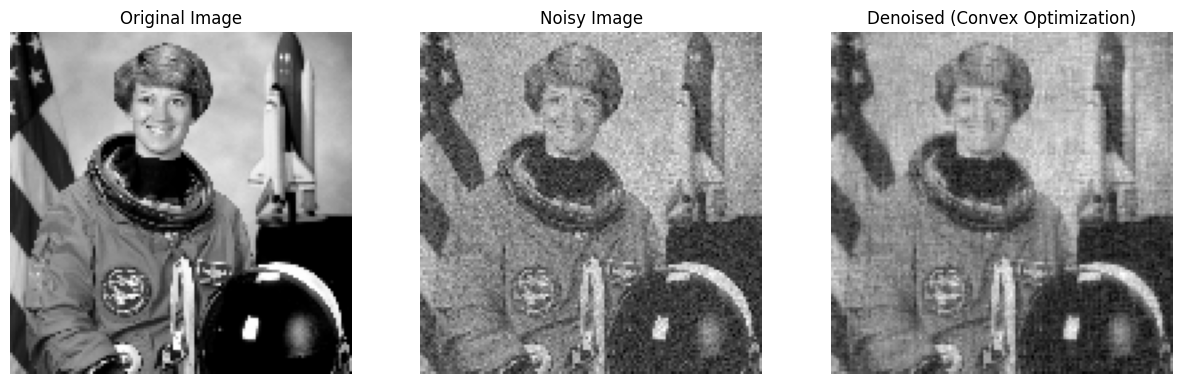

In [5]:
# Compute PSNR
psnr_noisy = psnr(original, noisy_image)
psnr_denoised = psnr(original, denoised_image)

print(f"PSNR (Noisy): {psnr_noisy:.2f} dB")
print(f"PSNR (After Denoising): {psnr_denoised:.2f} dB")

# Plot results
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].imshow(original, cmap='gray')
axs[0].set_title("Original Image")
axs[1].imshow(noisy_image, cmap='gray')
axs[1].set_title("Noisy Image")
axs[2].imshow(denoised_image, cmap='gray')
axs[2].set_title("Denoised (Convex Optimization)")
for ax in axs: ax.axis('off')
plt.show()


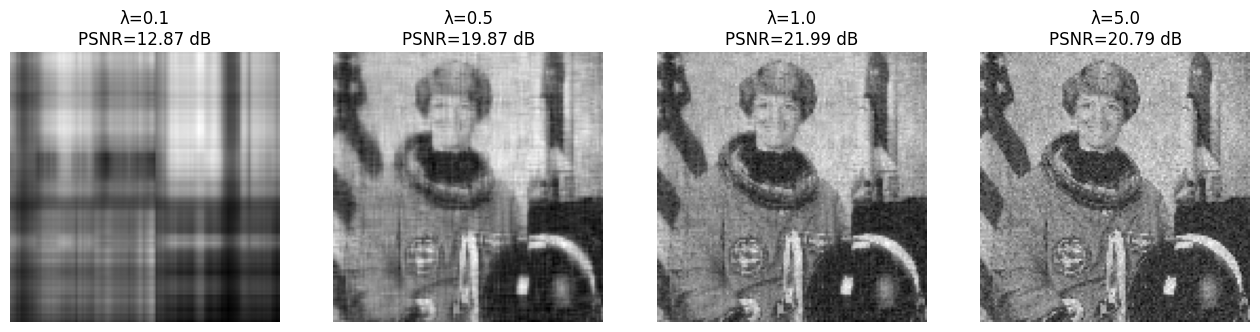

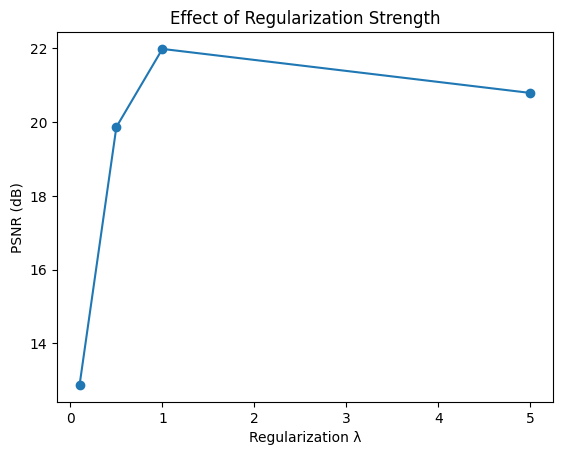

In [7]:
lambdas = [0.1, 0.5, 1.0, 5.0]
psnrs = []

fig, axs = plt.subplots(1, len(lambdas), figsize=(16, 4))
for i, lam in enumerate(lambdas):
    X = cp.Variable((m, n))
    objective = cp.Minimize(cp.normNuc(X) + (lam/2) * cp.norm(X - M, "fro")**2)
    prob = cp.Problem(objective)
    prob.solve()
    rec = X.value
    psnrs.append(psnr(original, rec))
    axs[i].imshow(rec, cmap='gray')
    axs[i].set_title(f"λ={lam}\nPSNR={psnrs[-1]:.2f} dB")
    axs[i].axis('off')

plt.show()

plt.plot(lambdas, psnrs, marker='o')
plt.xlabel("Regularization λ")
plt.ylabel("PSNR (dB)")
plt.title("Effect of Regularization Strength")
plt.show()


In [8]:
import pandas as pd
from google.colab import files

np.save("denoised_image.npy", denoised_image)
files.download("denoised_image.npy")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 🔬 Theoretical Discussion

This experiment demonstrates how **convex optimization** specifically, **nuclear norm minimization**, can be used as a relaxation for rank minimization in matrix problems.  

**Key ideas:**
- The **nuclear norm** serves as a convex surrogate for matrix rank.
- The objective trades off **low-rank structure** (via `||X||_*`) and **data fidelity** (via Frobenius norm).
- Such formulations are foundational in **matrix completion**, **compressed sensing**, and **statistical signal processing**.

**Relevance to Research Areas:**
- Links to **Sequential Convex Programming (SCP)** and **Semidefinite Programming (SDP)**.
- Connects optimization with **statistical estimation** and **image processing**.
- Demonstrates how convex relaxations can yield tractable and interpretable solutions for complex real-world data.

This small-scale example can easily be extended to:
- Dynamic or online reconstruction problems (relating to stochastic optimization).
- Large-scale convex solvers or proximal algorithms (relevant to numerical optimization theory).
- Statistical recovery guarantees under noisy observations (high-dimensional statistics).


In [9]:
# ADMM for Nuclear Norm Minimization
def singular_value_thresholding(X, tau):
    """Soft-thresholding operator for singular values."""
    U, S, Vt = np.linalg.svd(X, full_matrices=False)
    S_threshold = np.maximum(S - tau, 0)
    return U @ np.diag(S_threshold) @ Vt

# Parameters
rho = 1.0      # ADMM penalty parameter
max_iter = 200
tol = 1e-4
X = np.zeros_like(M)
Z = np.zeros_like(M)
U = np.zeros_like(M)  # dual variable
lambda_reg = 1.0

# ADMM iterations
for k in tqdm(range(max_iter)):
    # X-update: quadratic minimization
    X = (lambda_reg * M + rho * (Z - U)) / (lambda_reg + rho)

    # Z-update: singular value thresholding
    Z = singular_value_thresholding(X + U, 1/rho)

    # U-update: dual ascent
    U += X - Z

    # Convergence check
    if np.linalg.norm(X - Z, 'fro') / np.linalg.norm(M, 'fro') < tol:
        break

denoised_admm = Z


  4%|▍         | 9/200 [00:00<00:05, 33.72it/s]


PSNR (ADMM Denoising): 21.98 dB


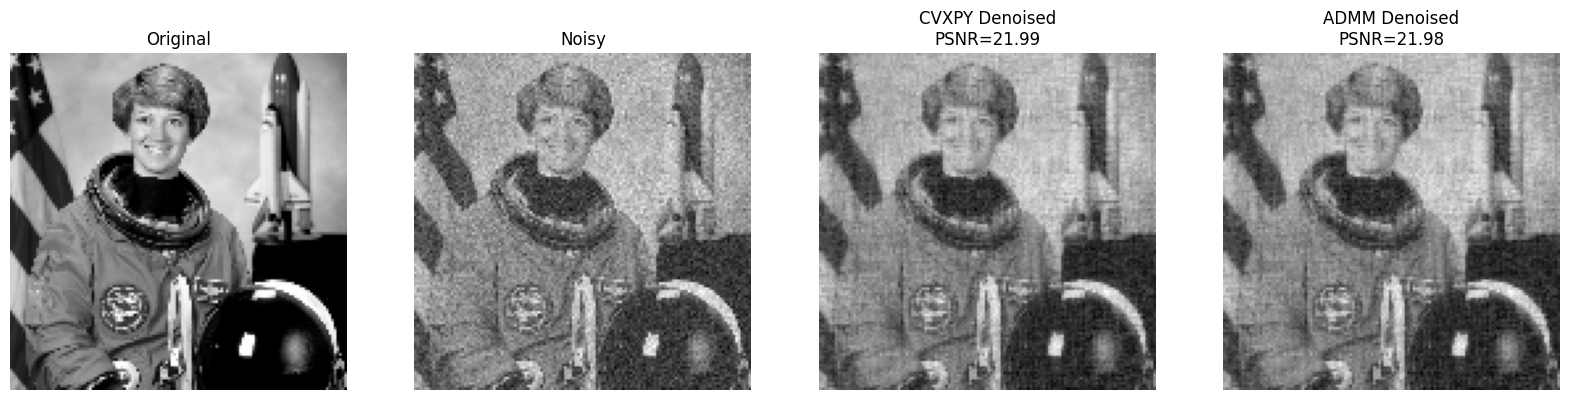

In [10]:
psnr_admm = psnr(original, denoised_admm)
print(f"PSNR (ADMM Denoising): {psnr_admm:.2f} dB")

# Plot side-by-side comparison
fig, axs = plt.subplots(1, 4, figsize=(20, 5))
axs[0].imshow(original, cmap='gray'); axs[0].set_title("Original"); axs[0].axis('off')
axs[1].imshow(noisy_image, cmap='gray'); axs[1].set_title("Noisy"); axs[1].axis('off')
axs[2].imshow(denoised_image, cmap='gray'); axs[2].set_title(f"CVXPY Denoised\nPSNR={psnr_denoised:.2f}"); axs[2].axis('off')
axs[3].imshow(denoised_admm, cmap='gray'); axs[3].set_title(f"ADMM Denoised\nPSNR={psnr_admm:.2f}"); axs[3].axis('off')
plt.show()
